# What does one surface-code extraction round cost the data?

## Premise

The paper treats idling and syndrome extraction as **separate knobs**. Per round, a data qubit
suffers `p_data ≈ p(1 + λΔt)`: extraction contributes `p` once per round, whatever the interval;
idling contributes `p·λ·Δt`, growing with the interval. λ is a hardware constant (idle
decoherence against the cost of one round), set independently of the gates. The optimal
interval exists only because the two terms can be traded against each other: measuring more
often buys less idling at the price of more extraction.

For that trade-off to be studied in Selene, idling has to be **controllable** and ideally
**independent of the extraction error**. Selene charges noise per native operation and has no
duration term, so idling is written in as `k` explicit `phased_x(q, 0, 0)` ops per τ unit, each
charged `p_1q`. With two-qubit noise off (`p_2q = 0`), every op in the compiled round is
charged the same `p_1q`:

```
extraction per round ≈ p_1q · n_data        idling per τ unit ≈ p_1q · k
λ = k / n_data                              (p_1q cancels)
```

**This notebook takes that route.** λ is fixed by circuit structure (`n_data`) and set only
through `k`, independent of the gate error rate: the paper's form, one error scale with λ a
fixed ratio. What it does not give is absolute independence: idling and extraction both move
with the one `p_1q`, so only their ratio is controllable.

The second route, `04c_extraction_cost_p2q`, turns on `p_2q`. That charges extraction at a rate
the idle ops never see, so λ is controlled through the gate-error ratio `p_2q/p_1q` instead.
Neither Selene route makes idling fully independent of the gates; the Stim arm
(`stim_memory.py`) does, with an idle channel over duration.

## What this notebook measures

The paper's model has two noise constants besides `p`: the idling rate λ, and the readout
multiplier `b_read` (see `docs/paper_equations.md`). In Selene neither is free. Selene charges
noise per native operation, so both are set by how many charged operations one syndrome
extraction round lands on each qubit:

```
λ (per idle op)  = 1 / n_data        n_data = charged ops per data qubit per round
b_read floor     = n_anc / n_data    n_anc  = charged ops per Z-ancilla per round
```

This notebook measures `n_data` (per qubit) and `n_anc` in Selene, for rotated and unrotated
surface codes at d = 3, 5, 7, and exports them to `config/surface_extraction_measured.yaml`,
which `04c`, `05`, `06` and `07` read.

**Result.**

| code | `n_data` | λ = 1/`n_data` | `b_read` floor |
| --- | --- | --- | --- |
| rotated d = 3, 5, 7 | 6.89, 8.40, 9.11 | 0.145, 0.119, 0.110 | 1.30, 1.18, 1.18 |
| unrotated d = 3, 5, 7 | 7.99, 9.30, 9.88 | 0.125, 0.108, 0.101 | 1.31, 1.19, 1.15 |

- λ is 0.10–0.15 with one idle op per τ unit: **2.1–3.1× below the 0.31** the paper fits to
  Willow (the value `05` uses at the paper's parameters). Idling is cheaper, relative to one
  round, than the paper assumes.
- The `b_read` floor is 1.15–1.31: **above the paper's `b_read = 1`**. Even with perfect
  readout, a syndrome bit is wrong more often than `p` alone implies.
- The cost of a round depends on **which end of each CNOT** a data qubit sits on: about
  1.4 charged ops as the control and 3.9 as the target (§5). So `p_stab` differs by up to
  3.2× between data qubits of the same code (§6).

## 0. Setup

Two noise scales, for two measurements: `p_1q = 0.001` for the data side, where flips
accumulate over up to 8 rounds and must stay in the regime where inverting them is linear;
`p_1q = 0.006` for the ancilla, measured over a single round where nothing accumulates.

In [1]:
# ---- the knobs -------------------------------------------------------------
# Two noise scales, for two different measurements:
P1Q      = 0.001    # the slope in R. Low, so the accumulated rate stays in the linear
                    # regime of the inversion (section 4).
P1Q_ANC  = 0.006    # the ancilla, measured at R=1 only. One round accumulates nothing,
                    # so there is no saturation exposure and the higher rate is precision.
ROUNDS   = (1, 2, 4, 6, 8)
SHOTS    = 12000
SEED     = 1

SWEEP = [("rotated", 3), ("rotated", 5), ("rotated", 7),
         ("unrotated", 3), ("unrotated", 5), ("unrotated", 7)]

LAMBDA_PAPER = 0.31   # the paper's Willow fit, as used in 05
B_READ_PAPER = 1.0
# ----------------------------------------------------------------------------

SPEC = {"rotated": "surface_code:rotated_memory_z",
        "unrotated": "surface_code:unrotated_memory_z"}

%matplotlib inline
import importlib.util, pathlib, sys, tempfile, time
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stim
import yaml

import sys; sys.path.insert(0, '../source')   # runcache, surface_memory
import runcache

# Reference palette, fixed order. Slots 1-3 validate under all-pairs comparison.
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
GRAY, INK, MUTED = '#8a8a86', '#0b0b0b', '#52514e'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c9c4', 'axes.labelcolor': MUTED, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'grid.color': '#e6e6e1',
    'legend.frameon': False, 'legend.fontsize': 8, 'font.size': 9, 'text.color': INK,
})
FIGDIR = pathlib.Path('figures'); FIGDIR.mkdir(exist_ok=True)
CONFIG = pathlib.Path.cwd().parent / "config"   # the repo's config/, next to notebooks/
pd.set_option('display.width', 150)


def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIGDIR / f'{name}.png', bbox_inches='tight', facecolor='white')
    plt.show()

## 1. The proxy circuit: both sectors, no Hadamards

To count charged ops per qubit, every data qubit has to read 1 **only** because of a fault.
The circuit is `|0⟩^n`, then the full extraction round, then a Z measurement of everything.

- **Z-checks** are fine as they are: the data qubit is the CNOT control, and with every data
  qubit in `|0⟩` the ancilla stays in `|0⟩`.
- **X-checks** are not: their ancilla is the control, prepared in `|+⟩` by an `h`. That
  entangles ancilla and data, and measuring the ancilla projects the data into the code space,
  after which each data qubit reads 1 about half the time with no fault at all.

**So the proxy drops the two `h` gates on each X-ancilla.** The ancilla stays in `|0⟩`, every
`cx(anc, data)` acts as the identity, and the data stay in `|0…0⟩`. Every CNOT still runs and
is still charged.

What this keeps: an X fault on a CNOT control propagates to the target whatever state the
control is in (`X_c · CNOT = CNOT · X_c X_t`). So a fault on an X-ancilla still reaches the
data, exactly as in a real round.

What it gives up: the two `h` gates per X-ancilla, 4 charged ops (notebook 03 measured
`h` = 2 charged ops). That affects neither the data side nor the Z-ancillas, and the Z-ancillas
are the only ones used for the `b_read` floor, because only Z-checks are decoded.

The CNOT order is read from Stim's generated circuit, not written by hand: the order decides
which faults propagate where.

In [2]:
def layout(spec, d):
    """Data qubits, Z/X stabiliser supports in CNOT order, and the logical support.

    Identical to 06's reader, so both notebooks execute the same geometry and, crucially,
    the same CNOT order -- the order is what decides how a fault propagates.
    """
    c = stim.Circuit.generated(spec, distance=d, rounds=1)
    anc, data_order, cx_pairs, obs = set(), [], [], []
    for inst in c.flattened():
        t = [g.value for g in inst.targets_copy() if g.is_qubit_target]
        if inst.name in ('CX', 'CNOT', 'ZCX'):
            cx_pairs += [(t[i], t[i + 1]) for i in range(0, len(t), 2)]
        elif inst.name in ('MR', 'MRZ'):
            anc.update(t)
        elif inst.name in ('M', 'MZ'):
            data_order = t
        elif inst.name == 'OBSERVABLE_INCLUDE':
            recs = [g.value for g in inst.targets_copy() if g.is_measurement_record_target]
            obs = [data_order[len(data_order) + r] for r in recs]
    data = [q for q in data_order if q not in anc]
    zsup, xsup = defaultdict(list), defaultdict(list)
    for ctrl, tgt in cx_pairs:
        if tgt in anc:
            zsup[tgt].append(ctrl)
        if ctrl in anc:
            xsup[ctrl].append(tgt)
    return dict(data=data, zanc=sorted(zsup), xanc=sorted(xsup),
                zsup=dict(zsup), xsup=dict(xsup), obs=obs, cx=cx_pairs)


LAYOUTS = {(c, d): layout(SPEC[c], d) for c, d in SWEEP}

rows = []
for (c, d), L in LAYOUTS.items():
    nd, nz, nx = len(L['data']), len(L['zanc']), len(L['xanc'])
    mult = np.array([sum(q in pair for pair in L['cx']) for q in L['data']])
    rows.append({'code': c, 'd': d, 'data': nd, 'Z-anc': nz, 'X-anc': nx,
                 'qubits': nd + nz + nx, 'CX': len(L['cx']),
                 'CX/data mean': round(mult.mean(), 3),
                 'CX/data spread': f"{mult.min()}-{mult.max()}"})
geom = pd.DataFrame(rows).set_index(['code', 'd'])
print(geom.to_string())
print("\nEvery code has data qubits on as few as 2 and as many as 4 CNOTs per round:")
print("boundary qubits sit in fewer checks than bulk ones.")

             data  Z-anc  X-anc  qubits   CX  CX/data mean CX/data spread
code      d                                                              
rotated   3     9      4      4      17   24         2.667            2-4
          5    25     12     12      49   80         3.200            2-4
          7    49     24     24      97  168         3.429            2-4
unrotated 3    13      6      6      25   40         3.077            2-4
          5    41     20     20      81  144         3.512            2-4
          7    85     42     42     169  312         3.671            2-4

Every code has data qubits on as few as 2 and as many as 4 CNOTs per round:
boundary qubits sit in fewer checks than bulk ones.


## 2. The Guppy program

The program is generated as source text and written to a real module file: Guppy reads the
decorated function with `inspect.getsourcelines`, so a function built from an `exec`'d string
has no source and does not compile.

There is no idling and no `h`: at τ = 0 the extraction round is the only thing that can flip
a data qubit. Printed below: the rotated d = 3 program for one round, 24 CNOTs.

In [3]:
from guppylang import guppy
from guppylang.std.angles import angle
from guppylang.std.builtins import array, output, py
from guppylang.std.quantum import collect_measurements, cx, h, measure, measure_array, qubit
from guppylang.std.qsystem import phased_x
from selene_sim import DepolarizingErrorModel, Stim, build

PREAMBLE = """from guppylang import guppy
from guppylang.std.angles import angle
from guppylang.std.builtins import array, output, py
from guppylang.std.quantum import collect_measurements, cx, h, measure, measure_array, qubit
from guppylang.std.qsystem import phased_x


"""

GEN_DIR = pathlib.Path(tempfile.mkdtemp(prefix='guppy_07_'))
_BUILT = {}


def proxy_source(L, rounds):
    """|0>^n, `rounds` extraction rounds over BOTH sectors, measure the data."""
    didx = {q: i for i, q in enumerate(L['data'])}
    aidx = {q: i for i, q in enumerate(L['zanc'] + L['xanc'])}
    o = ["@guppy", "def prog() -> None:",
         f"    qs = array(qubit() for _ in range(py({len(didx)})))",
         f"    for _ in range(py({rounds})):",
         f"        anc = array(qubit() for _ in range(py({len(aidx)})))"]
    for ctrl, tgt in L['cx']:
        cs = f"anc[{aidx[ctrl]}]" if ctrl in aidx else f"qs[{didx[ctrl]}]"
        ts = f"anc[{aidx[tgt]}]" if tgt in aidx else f"qs[{didx[tgt]}]"
        o.append(f"        cx({cs}, {ts})")
    # measure_array consumes the whole array at once: Guppy's linear types forbid
    # consuming a qubit out of an array by subscript.
    o.append('        output("s", collect_measurements(measure_array(anc)))')
    o.append('    output("data", collect_measurements(measure_array(qs)))')
    return "\n".join(o)


def runner(code, d, rounds):
    key = (code, d, rounds)
    if key not in _BUILT:
        name = f'proxy_{code}_d{d}_r{rounds}'
        path = GEN_DIR / f'{name}.py'
        path.write_text(PREAMBLE + proxy_source(LAYOUTS[(code, d)], rounds) + "\n")
        spec = importlib.util.spec_from_file_location(name, path)
        mod = importlib.util.module_from_spec(spec)
        sys.modules[name] = mod
        spec.loader.exec_module(mod)
        _BUILT[key] = build(mod.prog.compile())
    return _BUILT[key]


def run(code, d, rounds, shots=SHOTS, seed=SEED, **ch):
    """(syndromes [shots, rounds, n_anc], data [shots, n_data])."""
    L = LAYOUTS[(code, d)]
    nd, na = len(L['data']), len(L['zanc']) + len(L['xanc'])
    syn, dat = [], []
    # Each yielded shot is itself a lazy generator whose `with TCPStream` block spans the
    # whole loop: consume as it arrives or the child dies with ConnectionRefused.
    for shot in runner(code, d, rounds).run_shots(
            simulator=Stim(), n_qubits=nd + na, n_shots=shots,
            error_model=DepolarizingErrorModel(random_seed=seed, **ch), random_seed=seed):
        pairs = list(shot)
        syn.append([[int(b) for b in v] for k, v in pairs if k == "s"])
        dat.append([int(b) for b in [v for k, v in pairs if k == "data"][0]])
    return np.array(syn), np.array(dat)


print(proxy_source(LAYOUTS[("rotated", 3)], 1))

@guppy
def prog() -> None:
    qs = array(qubit() for _ in range(py(9)))
    for _ in range(py(1)):
        anc = array(qubit() for _ in range(py(8)))
        cx(anc[4], qs[1])
        cx(anc[6], qs[7])
        cx(anc[5], qs[5])
        cx(qs[6], anc[2])
        cx(qs[4], anc[0])
        cx(qs[8], anc[3])
        cx(anc[4], qs[0])
        cx(anc[6], qs[6])
        cx(anc[5], qs[4])
        cx(qs[3], anc[2])
        cx(qs[1], anc[0])
        cx(qs[5], anc[3])
        cx(anc[6], qs[4])
        cx(anc[5], qs[2])
        cx(anc[7], qs[8])
        cx(qs[3], anc[0])
        cx(qs[7], anc[3])
        cx(qs[5], anc[1])
        cx(anc[6], qs[3])
        cx(anc[5], qs[1])
        cx(anc[7], qs[7])
        cx(qs[0], anc[0])
        cx(qs[4], anc[3])
        cx(qs[2], anc[1])
        output("s", collect_measurements(measure_array(anc)))
    output("data", collect_measurements(measure_array(qs)))


## 3. Check: with the noise off, every bit must read 0

Noiseless, every data qubit and every ancilla must read 0: the Z-ancillas because their data
controls are in `|0⟩`, the X-ancillas because without `h` they never leave `|0⟩`. A single 1
anywhere means the product state was destroyed and per-qubit counts would be meaningless.
200 shots, 2 rounds, all six codes.

In [4]:
ok = []
for c, d in SWEEP:
    syn, dat = run(c, d, 2, shots=200, p_1q=0.0, p_2q=0.0, p_meas=0.0)
    ok.append({'code': c, 'd': d, 'data bits set': int(dat.sum()),
               'ancilla bits set': int(syn.sum())})
    assert dat.sum() == 0, f"{c} d={d}: data qubits must stay in |0>"
    assert syn.sum() == 0, f"{c} d={d}: ancillas must stay in |0>"
print(pd.DataFrame(ok).set_index(['code', 'd']).to_string())
print("\nthe proxy is logically inert on every configuration -- both sectors, no exceptions")

             data bits set  ancilla bits set
code      d                                 
rotated   3              0                 0
          5              0                 0
          7              0                 0
unrotated 3              0                 0
          5              0                 0
          7              0                 0

the proxy is logically inert on every configuration -- both sectors, no exceptions


## 4. Charged ops per data qubit per round

Flips compose mod 2, so a measured flip rate inverts to a number of charged ops:

```
n_eff = log(1 − 2·rate) / log(1 − 2f),      f = 2·p_1q/3
```

(`f = 2p/3` because `p_1q` is depolarizing and only X and Y flip `|0⟩`; notebook 03.)

`n_eff` is measured at R = 1, 2, 4, 6, 8 rounds and fitted per qubit as a straight line. The
**slope** is the cost of one round. If the round is the only thing acting, the **intercept**
is zero.

Two guards, both printed below:
- **Linearity.** The inversion is concave near rate 0.5, so the highest accumulated rate must
  stay small. At `p_1q = 0.001` the largest is 0.061.
- **Intercept.** Per-qubit intercepts from a five-point fit scatter widely, so the test is the
  signed mean over qubits in units of its own standard error; above 4 would mean something
  outside the round contributes.

In [5]:
def flip_per_op(p_1q):
    """Z-basis flip probability per charged 1q op: X and Y flip |0>, Z does not."""
    return 2 * p_1q / 3


def n_effective(rate, p_1q):
    f = flip_per_op(p_1q)
    r = np.clip(np.asarray(rate, float), 0, 0.4999)
    return np.log(1 - 2 * r) / np.log(1 - 2 * f)


def accumulated(n_ops, p_1q):
    """Flip rate after n_ops charged ops: the inverse of n_effective."""
    return (1 - (1 - 2 * flip_per_op(p_1q)) ** n_ops) / 2


def sigma(p, n):
    return np.sqrt(np.maximum(p * (1 - p), 1e-12) / n)


def sample(code, d, rounds, p_1q, shots=SHOTS):
    """Per-data-qubit flip rates and round-0 ancilla rates. Cached."""
    params = dict(code=code, d=d, rounds=rounds, p_1q=p_1q, p_2q=0.0,
                  shots=shots, seed=SEED, proxy="zero_state_both_sectors_no_h")
    hit = runcache.load("04_surface_extraction", params)
    if hit is not None:
        return hit
    L = LAYOUTS[(code, d)]
    didx = {q: i for i, q in enumerate(L['data'])}
    aidx = {q: i for i, q in enumerate(L['zanc'] + L['xanc'])}
    syn, dat = run(code, d, rounds, shots=shots, p_1q=p_1q)
    raw, local = [], []
    for a in L['zanc']:
        col = syn[:, 0, aidx[a]]
        clean = dat[:, [didx[q] for q in L['zsup'][a]]].sum(axis=1) == 0
        raw.append(float(col.mean()))
        local.append(float(col[clean].mean()))
    hit = {"data_rates": dat.mean(axis=0).tolist(), "z_raw": raw, "z_local": local,
           "n_clean": int(clean.sum())}
    runcache.save("04_surface_extraction", params, hit)
    return hit


t0 = time.time()
RAW = {(c, d): {r: sample(c, d, r, P1Q) for r in ROUNDS} for c, d in SWEEP}
ANC_RAW = {(c, d): sample(c, d, 1, P1Q_ANC, shots=6000) for c, d in SWEEP}
print(f"swept {len(SWEEP)} codes x {len(ROUNDS)} round counts [{time.time()-t0:.0f}s]")

R = np.array(ROUNDS, float)
FIT = {}
for c, d in SWEEP:
    L = LAYOUTS[(c, d)]
    didx = {q: i for i, q in enumerate(L['data'])}
    neff = np.array([n_effective(RAW[(c, d)][r]["data_rates"], P1Q) for r in ROUNDS])
    slope, icept = [], []
    for i in range(len(L['data'])):
        a, b = np.polyfit(R, neff[:, i], 1)
        slope.append(a); icept.append(b)
    # A data qubit is the CONTROL of its Z-checks and the TARGET of its X-checks.
    # The two ends of a CNOT do not cost the same, so they are counted separately.
    nc, nt = np.zeros(len(didx)), np.zeros(len(didx))
    for ctrl, tgt in L['cx']:
        if ctrl in didx:
            nc[didx[ctrl]] += 1
        if tgt in didx:
            nt[didx[tgt]] += 1
    FIT[(c, d)] = {'slope': np.array(slope), 'intercept': np.array(icept),
                   'n_ctrl': nc, 'n_tgt': nt, 'mult': nc + nt}

sat = pd.DataFrame([{
    'code': c, 'd': d,
    'n_data mean': round(FIT[(c, d)]['slope'].mean(), 3),
    'rate at R=8 (max qubit)': round(float(np.max(
        accumulated(FIT[(c, d)]['slope'] * 8, P1Q))), 4),
    'mean intercept': round(float(FIT[(c, d)]['intercept'].mean()), 3),
    'scatter (sd)': round(float(FIT[(c, d)]['intercept'].std()), 3),
    'sd / sqrt(n)': round(float(FIT[(c, d)]['intercept'].std()
                                / np.sqrt(len(FIT[(c, d)]['intercept']))), 3),
} for c, d in SWEEP]).set_index(['code', 'd'])
print("\n", sat.to_string())
worst_slope = max(FIT[k]['slope'].max() for k in FIT)
print(f"\nLinearity: the largest accumulated rate is {sat['rate at R=8 (max qubit)'].max():.3f}."
      f" At p_1q = {P1Q_ANC} the same")
print(f"qubit ({worst_slope:.1f} ops per round) would reach "
      f"{float(accumulated(worst_slope * 8, P1Q_ANC)):.2f} at R=8, where the inversion is biased.")
worst_t = max(abs(sat.loc[(c, d), 'mean intercept']) / sat.loc[(c, d), 'sd / sqrt(n)']
              for c, d in SWEEP)
print(f"\nIntercept: largest |signed mean| is {worst_t:.1f} standard errors from zero "
      f"(bar: 4). Individual")
print(f"per-qubit intercepts reach {max(np.abs(FIT[k]['intercept']).max() for k in FIT):.1f}"
      " ops; that is the scatter of a five-point fit, not a bias.")
print("VERDICT:", "consistent with zero -- the round is the only contributor"
      if worst_t < 4 else "a real bias: something outside the round contributes")

swept 6 codes x 5 round counts [0s]

              n_data mean  rate at R=8 (max qubit)  mean intercept  scatter (sd)  sd / sqrt(n)
code      d                                                                                  
rotated   3        6.889                   0.0573           0.702         0.631         0.210
          5        8.398                   0.0587           0.234         1.372         0.274
          7        9.114                   0.0589          -0.160         1.285         0.184
unrotated 3        7.991                   0.0558          -0.123         1.074         0.298
          5        9.300                   0.0612          -0.096         1.538         0.240
          7        9.878                   0.0596           0.117         1.290         0.140

Linearity: the largest accumulated rate is 0.061. At p_1q = 0.006 the same
qubit (12.2 ops per round) would reach 0.27 at R=8, where the inversion is biased.

Intercept: largest |signed mean| is 3.3 standard e

## 4b. Does a round cost the same however many surround it?

The compiler cancels some adjacent operations (`h;h`, `x;x`, `z;z`), and consecutive rounds
put each data qubit's operations back to back, so rounds could in principle merge. If they
did, the cost per round would depend on R, and so would λ.

Direct test, no fit: the cost of one round alone (R = 1) against the slope from §4, which is
the cost of adding one more round.

In [6]:
rows = []
for c, d in SWEEP:
    first = n_effective(RAW[(c, d)][1]["data_rates"], P1Q)   # one round, in isolation
    marg = FIT[(c, d)]['slope']                              # cost of adding a round
    rows.append({'code': c, 'd': d,
                 'first round (R=1)': round(float(first.mean()), 3),
                 'marginal round (slope)': round(float(marg.mean()), 3),
                 'first / marginal': round(float(first.mean() / marg.mean()), 3)})
merge = pd.DataFrame(rows).set_index(['code', 'd'])
print(merge.to_string())
dev = (merge['first / marginal'] - 1).abs().max()
print(f"\nLargest departure from 1: {dev:.3f}, and the ratios fall on both sides of it.")
print("VERDICT:", "no round-stacking effect -- rounds neither merge nor interfere"
      if dev < 0.10 else "rounds do NOT cost the same in isolation as in a stack")

             first round (R=1)  marginal round (slope)  first / marginal
code      d                                                             
rotated   3              7.454                   6.889             1.082
          5              8.584                   8.398             1.022
          7              9.014                   9.114             0.989
unrotated 3              7.916                   7.991             0.991
          5              9.361                   9.300             1.007
          7              9.931                   9.878             1.005

Largest departure from 1: 0.082, and the ratios fall on both sides of it.
VERDICT: no round-stacking effect -- rounds neither merge nor interfere


## 5. The two ends of a CNOT cost different amounts

A data qubit is the **control** of the CNOT for each of its Z-checks and the **target** for
each of its X-checks. If the two ends compile to different numbers of charged ops, one cost
per CNOT cannot describe the data.

Fit per code, over its data qubits:

```
ops per round = a · n_control + b · n_target        (two costs)
ops per round = c · (n_control + n_target)          (one cost per CNOT)
```

and compare the worst residual of each.

In [7]:
rows = []
for c, d in SWEEP:
    f = FIT[(c, d)]
    A = np.stack([f['n_ctrl'], f['n_tgt']], axis=1)
    (a, b), *_ = np.linalg.lstsq(A, f['slope'], rcond=None)
    res2 = np.abs(A @ np.array([a, b]) - f['slope']).max()
    # the one-parameter alternative: one cost for every CNOT, whichever end
    one = f['slope'].sum() / f['mult'].sum()
    res1 = np.abs(one * f['mult'] - f['slope']).max()
    f['a_ctrl'], f['b_tgt'] = a, b
    f['p_stab'] = accumulated(f['slope'], P1Q)
    rows.append({'code': c, 'd': d,
                 'control side': round(a, 3), 'target side': round(b, 3),
                 'worst resid (2-param)': round(res2, 2),
                 'single factor': round(one, 3),
                 'worst resid (1-param)': round(res1, 2)})
split = pd.DataFrame(rows).set_index(['code', 'd'])
print(split.to_string())
a_p = float(np.mean([FIT[k]['a_ctrl'] for k in FIT]))
b_p = float(np.mean([FIT[k]['b_tgt'] for k in FIT]))
r2 = float(split['worst resid (2-param)'].mean())
r1 = float(split['worst resid (1-param)'].mean())
print(f"\npooled over six codes: control side {a_p:.3f}, target side {b_p:.3f} charged ops "
      f"per CNOT ({b_p/a_p:.1f}x)")
print(f"worst residual, averaged over codes: {r2:.2f} ops with two costs, "
      f"{r1:.2f} with one cost per CNOT")

             control side  target side  worst resid (2-param)  single factor  worst resid (1-param)
code      d                                                                                        
rotated   3         1.489        3.738                   1.46          2.583                   2.50
          5         1.381        3.911                   2.47          2.625                   3.67
          7         1.396        3.941                   2.36          2.658                   3.60
unrotated 3         1.356        3.849                   1.53          2.597                   2.69
          5         1.491        3.831                   2.23          2.648                   3.36
          7         1.498        3.902                   2.41          2.691                   3.59

pooled over six codes: control side 1.435, target side 3.862 charged ops per CNOT (2.7x)
worst residual, averaged over codes: 2.08 ops with two costs, 3.23 with one cost per CNOT


## 6. `p_stab` is a vector

With two costs per CNOT, two data qubits with the same number of CNOTs still differ if one is
the target more often. Per data qubit, `p_stab = accumulate(ops per round, 2·p_1q/3)` at
`p_1q = 0.001`. Only its ratios are meaningful across `p_1q`; the absolute values scale with it.

In [8]:
summ = pd.DataFrame([{
    'code': c, 'd': d,
    'distinct (n_ctrl, n_tgt)': len(set(zip(FIT[(c, d)]['n_ctrl'].astype(int).tolist(),
                                            FIT[(c, d)]['n_tgt'].astype(int).tolist()))),
    'p_stab min': round(FIT[(c, d)]['p_stab'].min(), 6),
    'p_stab max': round(FIT[(c, d)]['p_stab'].max(), 6),
    'max/min': round(FIT[(c, d)]['p_stab'].max() / FIT[(c, d)]['p_stab'].min(), 2),
} for c, d in SWEEP]).set_index(['code', 'd'])
print(summ.to_string())

c0, d0 = "rotated", 3
f0 = FIT[(c0, d0)]
det = pd.DataFrame({'n_ctrl (Z-checks)': f0['n_ctrl'].astype(int),
                    'n_tgt (X-checks)': f0['n_tgt'].astype(int),
                    'total CX': f0['mult'].astype(int),
                    'ops per round': f0['slope'].round(3),
                    'predicted': (f0['a_ctrl'] * f0['n_ctrl']
                                  + f0['b_tgt'] * f0['n_tgt']).round(3),
                    'p_stab': f0['p_stab'].round(6)},
                   index=[f'q{i}' for i in range(len(f0['mult']))])
print(f"\n{c0} d={d0}, per data qubit:\n")
print(det.to_string())
print("\n'total CX' alone does not order p_stab: q1 and q5 both sit on 3 CNOTs, but q1 is the")
print("target twice and q5 once.")

             distinct (n_ctrl, n_tgt)  p_stab min  p_stab max  max/min
code      d                                                           
rotated   3                         4    0.002613    0.007547     2.89
          5                         4    0.002490    0.007741     3.11
          7                         4    0.002911    0.007773     2.67
unrotated 3                         4    0.002574    0.007338     2.85
          5                         4    0.002637    0.008092     3.07
          7                         4    0.002463    0.007868     3.19

rotated d=3, per data qubit:

    n_ctrl (Z-checks)  n_tgt (X-checks)  total CX  ops per round  predicted    p_stab
q0                  1                 1         2          4.984      5.227  0.003314
q1                  1                 2         3          9.998      8.966  0.006626
q2                  1                 1         2          5.879      5.227  0.003907
q3                  2                 1         3        

## 7. The Z-ancilla, and the `b_read` floor

A Z-ancilla fires either because a fault landed on the ancilla itself, or because a data fault
propagated onto it. Only the first is readout error. To separate them, the ancilla's rate is
taken **conditioned on its own data qubits reading 0** ("ancilla-local").

Measured at **R = 1** and `p_1q = 0.006`:
- **R = 1**, because the only data readout is the final one. At R = 1 it shows the data the
  ancilla saw; at R = 8, faults from later rounds contaminate the conditioning.
- **`p_1q = 0.006`**, because one round accumulates nothing, so a higher rate is safe and cuts
  the statistical error. 6,000 shots.

The result is an **upper bound**: a data fault that lands after its CNOT reaches the final
readout without ever touching the ancilla, so it passes the conditioning.

In [9]:
ANC = {}
rows = []
for c, d in SWEEP:
    local = float(np.mean(ANC_RAW[(c, d)]['z_local']))
    raw = float(np.mean(ANC_RAW[(c, d)]['z_raw']))
    ANC[(c, d)] = float(n_effective(local, P1Q_ANC))
    nd_m = float(FIT[(c, d)]['slope'].mean())
    s = sigma(local, 6000)
    rows.append({
        'code': c, 'd': d,
        'raw fire rate': round(raw, 4),
        'ancilla-local': round(local, 4),
        'n_anc': round(ANC[(c, d)], 3),
        'n_anc +/-': round(float(n_effective(local + s, P1Q_ANC) - ANC[(c, d)]), 2),
        'n_data': round(nd_m, 3),
        'b_read floor': round(ANC[(c, d)] / nd_m, 3),
    })
bread = pd.DataFrame(rows).set_index(['code', 'd'])
print(bread.to_string())
gap = (bread['raw fire rate'] / bread['ancilla-local'])
print(f"\nThe raw rate is {gap.min():.1f}-{gap.max():.1f}x the ancilla-local rate: most ancilla "
      "fires are propagated data faults.")
print(f"b_read floor: {bread['b_read floor'].min():.3f} to {bread['b_read floor'].max():.3f}, "
      f"above the paper's b_read = {B_READ_PAPER:g} on every code.")

             raw fire rate  ancilla-local   n_anc  n_anc +/-  n_data  b_read floor
code      d                                                                       
rotated   3         0.0638         0.0347   8.967       0.63   6.889         1.302
          5         0.0754         0.0382   9.889       0.67   8.398         1.177
          7         0.0844         0.0413  10.726       0.70   9.114         1.177
unrotated 3         0.0766         0.0403  10.464       0.69   7.991         1.309
          5         0.0864         0.0426  11.082       0.71   9.300         1.192
          7         0.0926         0.0436  11.363       0.72   9.878         1.150

The raw rate is 1.8-2.1x the ancilla-local rate: most ancilla fires are propagated data faults.
b_read floor: 1.150 to 1.309, above the paper's b_read = 1 on every code.


## 8. Measured constants against the paper's

λ with one idle op per τ unit (`k = 1`; notebooks 05–07 use this). λ scales with `k`, so
matching the paper's 0.31 would need `k` ≈ 2–3 idle ops per τ unit.

In [10]:
cmp_rows = []
for c, d in SWEEP:
    nd_m = float(FIT[(c, d)]['slope'].mean())
    na_m = ANC[(c, d)]
    lam = 1.0 / nd_m
    cmp_rows.append({
        'code': c, 'd': d,
        'n_data': round(nd_m, 3), 'n_anc': round(na_m, 3),
        'lambda': round(lam, 4),
        'paper / lambda': round(LAMBDA_PAPER / lam, 2),
        'b_read floor': round(na_m / nd_m, 4),
    })
cmp = pd.DataFrame(cmp_rows).set_index(['code', 'd'])
print(cmp.to_string())
print(f"\nlambda: {cmp['lambda'].min():.3f} to {cmp['lambda'].max():.3f} per idle op, "
      f"{cmp['paper / lambda'].min():.1f}-{cmp['paper / lambda'].max():.1f}x below the "
      f"paper's {LAMBDA_PAPER}.")
print(f"b_read floor: {cmp['b_read floor'].min():.2f} to {cmp['b_read floor'].max():.2f}, "
      f"against the paper's {B_READ_PAPER:g}.")

             n_data   n_anc  lambda  paper / lambda  b_read floor
code      d                                                      
rotated   3   6.889   8.967  0.1452            2.14        1.3017
          5   8.398   9.889  0.1191            2.60        1.1774
          7   9.114  10.726  0.1097            2.83        1.1768
unrotated 3   7.991  10.464  0.1251            2.48        1.3095
          5   9.300  11.082  0.1075            2.88        1.1916
          7   9.878  11.363  0.1012            3.06        1.1503

lambda: 0.101 to 0.145 per idle op, 2.1-3.1x below the paper's 0.31.
b_read floor: 1.15 to 1.31, against the paper's 1.


## 9. Export

Written to `config/surface_extraction_measured.yaml`. `04c`, `05`, `06` and `07` read the
per-qubit `ops_per_round`, `ancilla_z`, `lambda_per_idle_op` and `b_read_floor` from it.

In [11]:
import datetime

out = {
    "provenance": {
        "notebook": "notebooks/04_extraction_cost_surface.ipynb",
        "generated": datetime.date.today().isoformat(),
        "shots": int(SHOTS),
        "p_1q_slope": float(P1Q),
        "p_1q_ancilla": float(P1Q_ANC),
        "rounds_swept": list(ROUNDS),
        "seed": int(SEED),
        "proxy": ("|0>^n product state, both sectors extracted, Hadamards omitted on the "
                  "X-check ancillas so the round stays logically inert while every CNOT "
                  "is still charged"),
    },
    "conversion_by_cnot_end": {
        "note": "charged ops per CNOT at each end, pooled over the six codes",
        "surface_control_side": round(float(np.mean([FIT[k]['a_ctrl'] for k in FIT])), 3),
        "surface_target_side": round(float(np.mean([FIT[k]['b_tgt'] for k in FIT])), 3),
    },
    "surface_measured": {},
    "limits": {
        "note": ("X faults only (Z-basis readout); b_read_floor is an upper bound, since a "
                 "data fault landing after its CNOT reaches the readout without reaching "
                 "the ancilla; p_stab is proportional to p_1q and so is provenance only -- "
                 "only lambda and b_read_floor are scale-free. The X-ancilla loses 2 h "
                 "gates (4 charged ops) relative to a real round; this touches neither the "
                 "data side nor the Z-ancillas, which are what the exported ratios use. "
                 "p_2q is zero throughout, so correlated data<->ancilla faults are absent. "
                 "Per-qubit marginals only: which qubits fail together is not recorded."),
    },
}

for c, d in SWEEP:
    L = LAYOUTS[(c, d)]
    f = FIT[(c, d)]
    nd_m = float(f['slope'].mean())
    out["surface_measured"][f"{c}_d{d}"] = {
        "status": "measured in Selene",
        "data_qubits": len(L['data']),
        "z_ancillas": len(L['zanc']),
        "x_ancillas": len(L['xanc']),
        "cx_total": len(L['cx']),
        "n_control_per_data": [int(x) for x in f['n_ctrl']],
        "n_target_per_data": [int(x) for x in f['n_tgt']],
        "ops_per_round": {
            "data_per_qubit": [round(float(x), 3) for x in f['slope']],
            "data_mean": round(nd_m, 3),
            "ancilla_z": round(float(ANC[(c, d)]), 3),
        },
        "ops_per_cx_control_side": round(float(f['a_ctrl']), 3),
        "ops_per_cx_target_side": round(float(f['b_tgt']), 3),
        "p_stab": {
            "per_qubit": [round(float(x), 7) for x in f['p_stab']],
            "mean": round(float(f['p_stab'].mean()), 7),
            "note": f"at p_1q = {P1Q}; proportional to p_1q, so NOT scale-free",
        },
        "lambda_per_idle_op": round(1.0 / nd_m, 4),
        "b_read_floor": round(float(ANC[(c, d)]) / nd_m, 4),
    }

CONFIG.mkdir(exist_ok=True)
path = CONFIG / "surface_extraction_measured.yaml"
path.write_text(yaml.safe_dump(out, sort_keys=False))
print(f"wrote config/{path.name}\n")
print(path.read_text()[:1200], "\n...")

wrote config/surface_extraction_measured.yaml

provenance:
  notebook: notebooks/04_extraction_cost_surface.ipynb
  generated: '2026-09-30'
  shots: 12000
  p_1q_slope: 0.001
  p_1q_ancilla: 0.006
  rounds_swept:
  - 1
  - 2
  - 4
  - 6
  - 8
  seed: 1
  proxy: '|0>^n product state, both sectors extracted, Hadamards omitted on the X-check
    ancillas so the round stays logically inert while every CNOT is still charged'
conversion_by_cnot_end:
  note: charged ops per CNOT at each end, pooled over the six codes
  surface_control_side: 1.435
  surface_target_side: 3.862
surface_measured:
  rotated_d3:
    status: measured in Selene
    data_qubits: 9
    z_ancillas: 4
    x_ancillas: 4
    cx_total: 24
    n_control_per_data:
    - 1
    - 1
    - 1
    - 2
    - 2
    - 2
    - 1
    - 1
    - 1
    n_target_per_data:
    - 1
    - 2
    - 1
    - 1
    - 2
    - 1
    - 1
    - 2
    - 1
    ops_per_round:
      data_per_qubit:
      - 4.984
      - 9.998
      - 5.879
      - 7.96
   

## 10. Figures

Left figure: rotated d = 3, measured ops per round for each data qubit against the two-cost fit
`a·n_control + b·n_target`. Labels give each qubit's count of control and target CNOTs.

Right figure: λ and the `b_read` floor against distance, with the paper's 0.31 and 1.

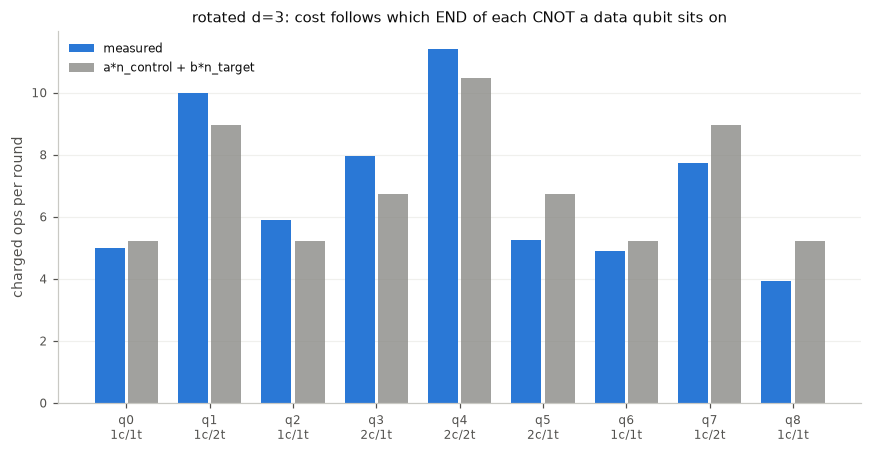

In [12]:
c0, d0 = "rotated", 3
f0 = FIT[(c0, d0)]
fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(len(f0['slope']))
ax.bar(x - 0.2, f0['slope'], width=0.36, color=BLUE, label='measured')
ax.bar(x + 0.2, f0['a_ctrl'] * f0['n_ctrl'] + f0['b_tgt'] * f0['n_tgt'], width=0.36,
       color=GRAY, alpha=.8, label='a*n_control + b*n_target')
ax.set_xticks(x, [f'q{i}\n{int(a)}c/{int(b)}t'
                  for i, (a, b) in enumerate(zip(f0['n_ctrl'], f0['n_tgt']))])
ax.set_ylabel('charged ops per round')
ax.set_title(f'{c0} d={d0}: cost follows which END of each CNOT a data qubit sits on')
ax.grid(axis='y', alpha=.6); ax.set_axisbelow(True); ax.legend(loc='upper left')
finish(fig, '04s_a_surface_p_stab_per_qubit')

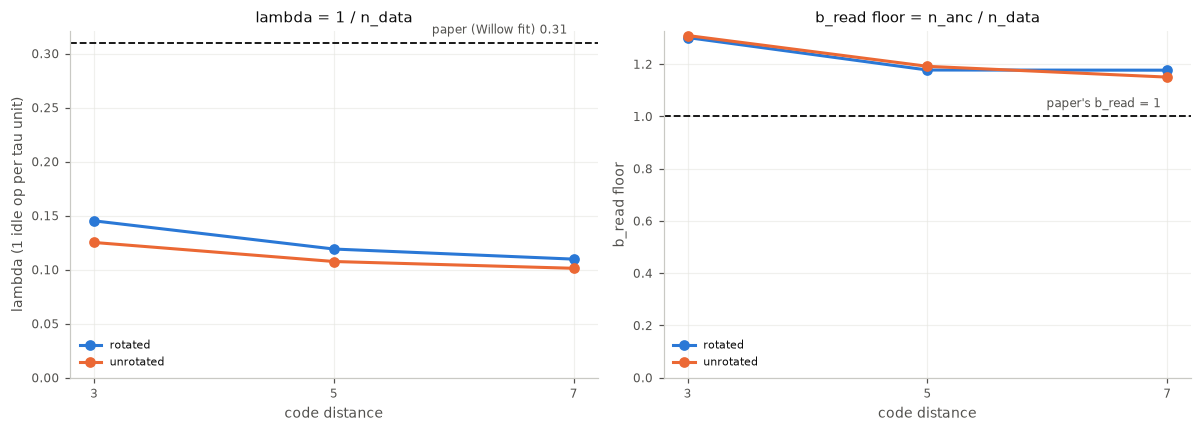

In [13]:
ds = [3, 5, 7]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lab, colour in (('rotated', BLUE), ('unrotated', ORANGE)):
    axes[0].plot(ds, [1.0 / FIT[(lab, d)]['slope'].mean() for d in ds],
                 marker='o', ms=6, lw=2, color=colour, label=lab)
    axes[1].plot(ds, [ANC[(lab, d)] / FIT[(lab, d)]['slope'].mean() for d in ds],
                 marker='o', ms=6, lw=2, color=colour, label=lab)
axes[0].axhline(LAMBDA_PAPER, color=INK, lw=1.2, ls='--')
axes[0].annotate(f"paper (Willow fit) {LAMBDA_PAPER}", (7, LAMBDA_PAPER), xytext=(-4, 6),
                 textcoords='offset points', ha='right', fontsize=8, color=MUTED)
axes[0].set_ylim(0, None)
axes[0].set_ylabel('lambda (1 idle op per tau unit)')
axes[0].set_title('lambda = 1 / n_data')
axes[1].axhline(B_READ_PAPER, color=INK, lw=1.2, ls='--')
axes[1].annotate(f"paper's b_read = {B_READ_PAPER:g}", (7, B_READ_PAPER), xytext=(-4, 6),
                 textcoords='offset points', ha='right', fontsize=8, color=MUTED)
axes[1].set_ylim(0, None)
axes[1].set_ylabel('b_read floor')
axes[1].set_title('b_read floor = n_anc / n_data')
for a in axes:
    a.set_xlabel('code distance'); a.set_xticks(ds); a.grid(alpha=.6)
    a.set_axisbelow(True); a.legend(fontsize=7)
finish(fig, '04s_b_lambda_and_b_read')

## 11. Findings

**1. λ is 0.10–0.15 per idle op, 2.1–3.1× below the paper's 0.31.** λ = 1/`n_data`, and a
surface-code round lands 6.9–9.9 charged ops on the average data qubit. It falls with d
(rotated 0.145 → 0.110, unrotated 0.125 → 0.101) because bulk data qubits sit on more CNOTs
than boundary ones, and larger codes have proportionally more bulk. Matching 0.31 would take
`k` ≈ 2–3 idle ops per τ unit.

**2. The `b_read` floor is 1.15–1.31, above the paper's `b_read = 1`.** A Z-ancilla takes
9.0–11.4 charged ops per round, more than the average data qubit, so a syndrome bit is wrong
more often than `p` alone implies, however good the readout.

**3. The two ends of a CNOT cost different amounts.** Pooled over six codes: 1.44 charged ops
as the control, 3.86 as the target, 2.7× apart. The two-cost fit leaves a worst residual of
2.08 ops (averaged over codes) against 3.23 for one cost per CNOT, and its coefficients agree
across all six codes (control 1.36–1.50, target 3.74–3.94).

**4. `p_stab` differs by up to 3.2× between data qubits of one code** (max/min 2.67–3.19).
Total CNOT count does not order it: in rotated d = 3, q1 and q5 both sit on 3 CNOTs, but q1
is the target twice and costs 10.0 ops per round against q5's 5.3.

**5. A round costs the same however many surround it.** One round alone costs within 8% of a
round added to a stack (within 2% at d ≥ 5; the 8% is rotated d = 3), and the signed mean
intercept is at most 3.3 standard errors from zero, under the bar of 4. So "ops per round" is
one number, and λ is well defined per round for the 3–96 round range `06` sweeps.

### Limits

- **X faults only.** The readout is in Z; the Z component of the depolarizing noise is
  present but not seen here.
- **The `b_read` floor is an upper bound** and the noisiest number here (±0.63–0.72 ops on
  `n_anc`).
- **Two conventions.** `n_data` is a slope over R = 1–8; `n_anc` is a single round. Finding 5
  shows the two agree within 8% on the data side; it is not checked on the ancilla side.
- **Two noise scales**, `p_1q = 0.001` and 0.006. Only the ratios λ and `b_read` floor are
  scale-free, so combining them is valid, but they are two experiments.
- **`p_2q = 0`**, so λ here depends on `k` alone. `04c_extraction_cost_p2q` is the second route:
  it lowers λ by raising two-qubit gate error, and measures the correlated data–ancilla faults
  that brings.
- **Per-qubit marginals only.** Which qubits fail *together* is discarded, and that is what a
  matching decoder's edge weights need.

### Next

1. Count native ops per data qubit directly from the compiled program. That is a second route
   to `n_data`, with no inversion.
2. Measure the ancilla as a slope over R, like the data, so the floor is a ratio of two
   per-round costs.
3. Keep the joint fault pattern, not just per-qubit marginals.